## 1. Environment setup

Import the project library `ProxiPal`, which wraps all standard scientific dependencies (pandas, numpy, scipy, matplotlib). Ensures the parent directory is on `sys.path` so the local module is found regardless of working directory.

In [1]:
# ── Environment setup ─────────────────────────────────────────────────────────
# ProxiPal is the project's custom analysis library (ProxiPal.py in repo root).
# It re-exports pandas, numpy, scipy, and matplotlib — no need to import them
# separately after this cell.

import sys
from pathlib import Path

module_dir = Path.cwd().parent          # navigate up one level to repo root
sys.path.append(str(module_dir))        # make ProxiPal importable

from ProxiPal import *
# See: https://github.com/jeffsmith8/NfL-iPLA-paper


OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-06-08 17:30:08
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\iPLAvsOlink
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\smith.j\OneDriv

## 2. Load data

Read the two input CSVs:
- **`MiND_Olink_PLA_Simoa_withOlinkCt.csv`** — manually curated file merging iPLA, Simoa, and Olink results for the MiND cohort.
- **`pooled_standards_values.csv`** — pooled standards Ct values used to derive the global standard curve.

`sample_type` labels are normalised here to canonical form (`'Li-Hep plasma'`, `'EDTA plasma'`) used throughout all downstream figures.

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
# Manually curated file merging iPLA, Simoa, and Olink outputs for the MiND cohort.
data = pd.read_csv('MiND_Olink_PLA_Simoa_withOlinkCt.csv', low_memory=False)

# Pooled standards Ct values — used to fit the global standard curve below.
data_std = pd.read_csv('pooled_standards_values.csv', low_memory=False)

# Normalise sample_type labels to canonical form used in all figures.
# Raw labels from the source file differ in capitalisation/spacing.
sample_type_map = {
    'Li Hep Plasma': 'Li-Hep plasma',
    'EDTA Plasma':   'EDTA plasma',
}
data['sample_type'] = data['sample_type'].map(sample_type_map).fillna(data['sample_type'])


## 3. Global standard curve

Fit a single linear regression (Ct ~ log₁₀[NfL pg/mL]) pooled across all iPLA runs. The resulting slope (`m`) and intercept (`c`) define the **global standard curve** used to back-calculate concentration from Ct in every sample. Pooling across runs reduces run-to-run calibration noise.

Text(0.5, 1.0, 'Global standard curve: Ct = -3.363 * log10(pg/ml) + 25.435')

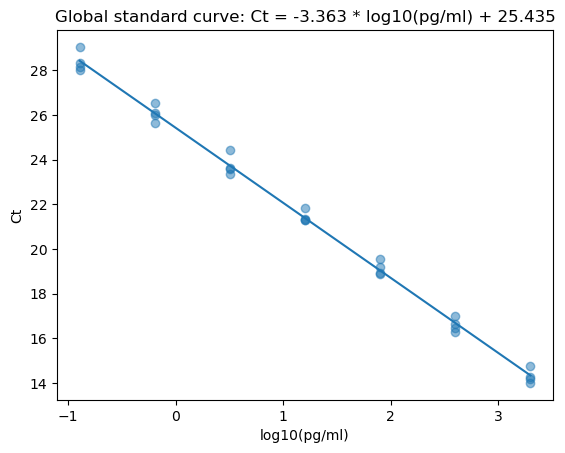

In [3]:
# ── Global standard curve ─────────────────────────────────────────────────────
# Melt the wide standards table to long format so all runs contribute equally
# to a single pooled regression.

std = data_std.drop(columns=[c for c in data_std.columns if c.startswith("Unnamed")], errors="ignore")

long = std.melt(
    id_vars=["pg/ml", "log10(pg/ml)"],  # concentration columns as id vars
    var_name="filepath_csv",             # one column per run in the wide table
    value_name="ct"                      # melted Ct values
)

long = long.dropna(subset=["log10(pg/ml)", "ct"])   # remove rows with missing Ct

# Fit Ct = m * log10(pg/ml) + c  across all pooled standards
X = long["log10(pg/ml)"].to_numpy().reshape(-1, 1)
y = long["ct"].to_numpy()

model = LinearRegression()
model.fit(X, y)

m = float(model.coef_[0])       # slope (Ct units per log10 pg/mL)
c = float(model.intercept_)     # intercept

# Quick diagnostic plot — not publication quality, just to verify fit
fig, ax = plt.subplots()
ax.scatter(long["log10(pg/ml)"], long["ct"], alpha=0.5)

x_line = np.linspace(long["log10(pg/ml)"].min(), long["log10(pg/ml)"].max(), 200)
y_line = m * x_line + c
ax.plot(x_line, y_line)

ax.set_xlabel("log10(pg/ml)")
ax.set_ylabel("Ct")
ax.set_title(f"Global standard curve: Ct = {m:.3f} * log10(pg/ml) + {c:.3f}")


## 4. Back-calculate global-adjusted Ct

Convert the per-sample iPLA concentration (already back-calculated from each run's own standard curve, stored in `SLR; log10(x); exc_std0; ct; mean_ng/L`) into a **global-adjusted Ct** using the pooled curve parameters.

The dilution factor correction (`/ dilution`) brings values back to undiluted concentration space before applying the global curve. This makes Ct values directly comparable across runs and dilutions.

In [4]:
# ── Back-calculate global-adjusted Ct ────────────────────────────────────────
# Hard-coded global curve parameters from the fit above.
# Using fixed values here ensures reproducibility independent of re-running cell 3.
m_global = -3.363
c_global = 25.435

col_C   = "SLR; log10(x); exc_std0; ct; mean_ng/L"   # per-run back-calculated concentration (ng/L)
col_dil = "dilution"                                   # sample dilution factor

# Only compute where concentration is positive (log10 is undefined otherwise)
mask = data[col_C] > 0

# Ct_global_adjusted = m * log10(conc_undiluted) + c
# Dividing by dilution converts from diluted to undiluted concentration space.
data.loc[mask, "Ct_global_adjusted"] = (
    m_global * np.log10(data.loc[mask, col_C] / data.loc[mask, col_dil]) + c_global
)

data.head(1)


,row,sample_id,sample_type,filepath_csv,ct,ct; mean,dilution,usr_mean_ng/L,SLR; log10(x); exc_std0; ct; mean_ng/L,SLR; log10(x); exc_std0; rdml_log2N0 (mean eff) - no plateau - stat efficiency; mean_ng/L,SLR; log10(x); exc_std0; ct; grad,SLR; log10(x); exc_std0; ct; y_int,SLR; log10(x); exc_std0; ct; equation,SLR; log10(x); exc_std0; ct; R2,SLR; log10(x); exc_std0; ct; PCReff,NPX,Olink Ct,simoa_pg/ml,Ct_global_adjusted
0,5239,NFL001LH,Li-Hep plasma,240620_e69_kruti/240620/240620_NfL-e69_kruti.csv,23.016,22.947,10,45.09,45.0357,43.4969,-3.315695,25.113995,y = -3.3157e+00x + 2.5114e+01,0.998035,100.26,3.83175,17.91265,NaN,23.237088


## 5. Derive PLA log₂ signal

Define a sign-flipped version of `Ct_global_adjusted` as a convenience column for regression against Olink NPX. Since Ct decreases as concentration increases, negating it produces a signal that scales in the same direction as NPX (higher = more protein), making regression coefficients more interpretable.

In [5]:
# ── PLA log2 signal ───────────────────────────────────────────────────────────
# Olink NPX increases with concentration; Ct decreases.
# Negating Ct aligns directionality for regression — higher signal = more protein.
# This is equivalent to a log2-scale signal up to an additive constant.
data["PLA_log2_signal"] = -data["Ct_global_adjusted"]


## 6. OLS regression summary: NPX ~ PLA log₂ signal

Fit a simple OLS model to quantify the linear relationship between iPLA signal and Olink NPX. The full statsmodels summary gives R², F-statistic, coefficient SE, and confidence intervals — used to assess method agreement before plotting.

In [6]:
# ── OLS: NPX ~ PLA log2 signal ───────────────────────────────────────────────
import statsmodels.api as sm

# Restrict to rows with both NPX and PLA signal present
mask = data[["NPX", "PLA_log2_signal"]].notna().all(axis=1)
df_cmp = data.loc[mask, ["NPX", "PLA_log2_signal"]]

X = sm.add_constant(df_cmp["PLA_log2_signal"])  # add intercept term
y = df_cmp["NPX"]
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    NPX   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     294.5
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           7.44e-21
Time:                        17:30:17   Log-Likelihood:                -16.486
No. Observations:                  45   AIC:                             36.97
Df Residuals:                      43   BIC:                             40.59
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              24.0138      1.308     

## 7. Draft plot: NPX vs Ct (exploratory)

Quick exploratory scatter to verify axis inversion and regression direction before committing to publication style. X-axis is inverted because higher Ct = lower concentration — inversion puts higher concentration on the right, consistent with NPX directionality.

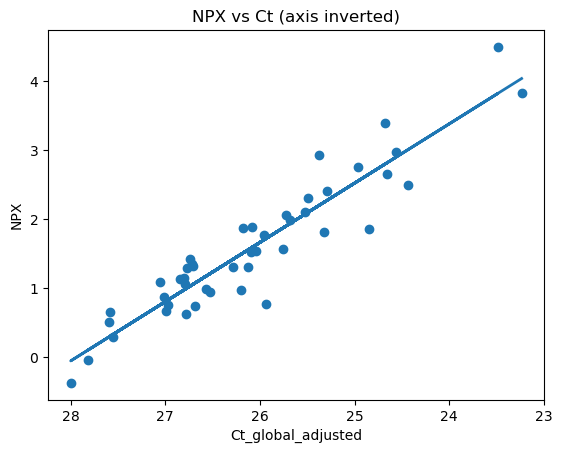

In [7]:
# ── Draft scatter: NPX vs Ct ──────────────────────────────────────────────────
# Exploratory only — not publication quality. Used to verify data and axis direction.

x = data["Ct_global_adjusted"]
y = data["NPX"]

mask = x.notna() & y.notna()
xv = x[mask]
yv = y[mask]

import statsmodels.api as sm

X = sm.add_constant(xv)
mod = sm.OLS(yv, X).fit()

a = mod.params["const"]
b = mod.params["Ct_global_adjusted"]

plt.figure()
plt.scatter(xv, yv)
plt.plot(xv, a + b * xv, linewidth=2)
plt.gca().invert_xaxis()    # higher concentration → right
plt.xlabel("Ct_global_adjusted")
plt.ylabel("NPX")
plt.title("NPX vs Ct (axis inverted)")
plt.show()


## 8. Draft publication plot: iPLA Ct vs Olink NPX by matrix (v1)

Intermediate version of the iPLA Ct vs Olink NPX comparison plot, coloured by sample matrix. This version uses a text annotation box for stats rather than legend proxies. Superseded by the final publication-style version in the next cell.

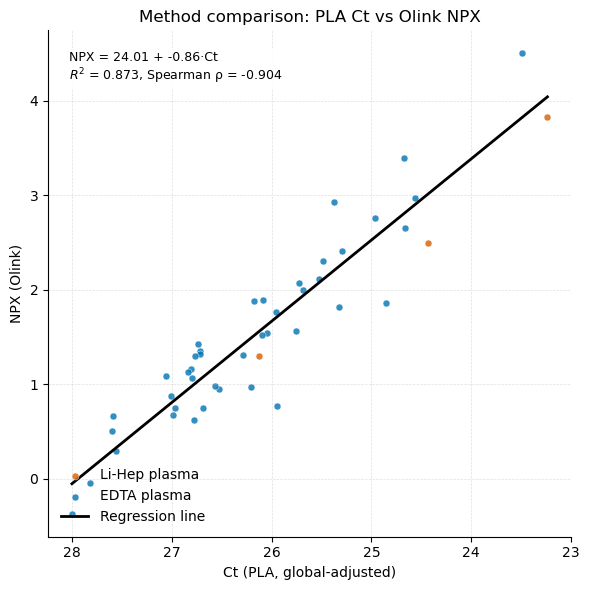

In [8]:
# ── Draft publication scatter: NPX vs Ct by matrix (v1) ──────────────────────
# Intermediate version — stats in text box, not legend. Superseded by next cell.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr

df = data.loc[data["Ct_global_adjusted"].notna() & data["NPX"].notna()].copy()

x = df["Ct_global_adjusted"]
y = df["NPX"]

X = sm.add_constant(x)
mod = sm.OLS(y, X).fit()
a   = mod.params["const"]
b   = mod.params["Ct_global_adjusted"]
r2  = mod.rsquared
rho, rho_p = spearmanr(x, y)

x_grid = np.linspace(x.min(), x.max(), 200)
y_fit  = a + b * x_grid

type_colors = {
    "Li-Hep plasma": "#D55E00",
    "EDTA plasma":   "#0072B2",
}

plt.figure(figsize=(6, 6))

if "sample_type" in df.columns:
    for st in df["sample_type"].unique():
        sub = df[df["sample_type"] == st]
        plt.scatter(
            sub["Ct_global_adjusted"], sub["NPX"],
            s=25, alpha=0.8, edgecolor="white", linewidth=0.4,
            label=st, color=type_colors.get(st, "0.5"),
        )
else:
    plt.scatter(x, y, s=25, alpha=0.8, edgecolor="white",
                linewidth=0.4, color="#0072B2", label="Samples")

plt.plot(x_grid, y_fit, color="black", linewidth=2, label="Regression line")

ax = plt.gca()
ax.invert_xaxis()
ax.set_xlabel("Ct (PLA, global-adjusted)")
ax.set_ylabel("NPX (Olink)")
ax.set_title("Method comparison: PLA Ct vs Olink NPX")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

txt = (
    f"NPX = {a:.2f} + {b:.2f}·Ct\n"
    f"$R^2$ = {r2:.3f}, Spearman ρ = {rho:.3f}"
)
ax.text(0.04, 0.96, txt, transform=ax.transAxes,
        ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, linewidth=0))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()


## 9. Final publication plot: iPLA Ct vs Olink NPX

Publication-quality figure following house style: 88 mm single-column width, 6 pt Helvetica, Okabe-Ito palette, open markers (triangle = Li-Hep, square = EDTA), stats in legend proxies rather than text box. Saved as SVG at 300 DPI.

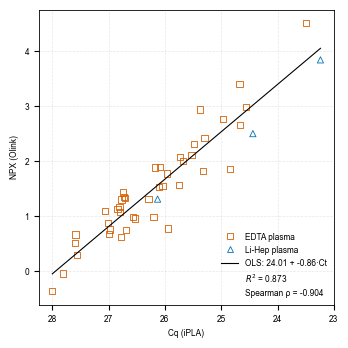

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# ── Global rcParams ───────────────────────────────────────────────────────────
plt.rcParams['font.family']        = 'sans-serif'
plt.rcParams['font.sans-serif']    = ['Helvetica', 'Arial']
plt.rcParams['font.size']          = 6
plt.rcParams['axes.titlesize']     = 6
plt.rcParams['axes.labelsize']     = 6
plt.rcParams['xtick.labelsize']    = 6
plt.rcParams['ytick.labelsize']    = 6
plt.rcParams['legend.fontsize']    = 6
plt.rcParams['axes.linewidth']     = 0.6
plt.rcParams['scatter.edgecolors'] = 'none'

# ── Okabe-Ito palette ─────────────────────────────────────────────────────────
okabe_ito = {
    'orange':         '#E69F00',
    'sky blue':       '#56B4E9',
    'bluish green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermillion':     '#D55E00',
    'reddish purple': '#CC79A7',
    'black':          '#000000',
}
matrix_colours = {
    'EDTA plasma':   okabe_ito['vermillion'],
    'Li-Hep plasma': okabe_ito['blue'],
}
matrix_markers = {
    'EDTA plasma':   's',
    'Li-Hep plasma': '^',
}

# ── Data prep ─────────────────────────────────────────────────────────────────
df = data.loc[data["Ct_global_adjusted"].notna() & data["NPX"].notna()].copy()

sample_type_map = {
    'Li Hep Plasma': 'Li-Hep plasma',
    'EDTA Plasma':   'EDTA plasma',
}
df['sample_type'] = df['sample_type'].map(sample_type_map).fillna(df['sample_type'])

x = df["Ct_global_adjusted"]
y = df["NPX"]

# ── OLS regression ────────────────────────────────────────────────────────────
X = sm.add_constant(x)
mod = sm.OLS(y, X).fit()
a   = mod.params["const"]
b   = mod.params["Ct_global_adjusted"]
r2  = mod.rsquared
rho, _ = spearmanr(x, y)

x_grid = np.linspace(x.min(), x.max(), 200)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

if "sample_type" in df.columns:
    for st, sub in df.groupby("sample_type"):
        ax.scatter(
            sub["Ct_global_adjusted"], sub["NPX"],
            s=20, marker=matrix_markers.get(st, 'o'),
            facecolors='none', edgecolors=matrix_colours.get(st, okabe_ito['black']),
            linewidths=0.6, zorder=3
        )
else:
    ax.scatter(
        x, y,
        s=20, marker='o',
        facecolors='none', edgecolors=okabe_ito['blue'],
        linewidths=0.6, zorder=3, label='Samples'
    )

ax.plot(x_grid, a + b * x_grid,
        color=okabe_ito['black'], linewidth=0.8, zorder=4)

ax.invert_xaxis()
ax.set_xlabel('Cq (iPLA)')
ax.set_ylabel('NPX (Olink)')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

# ── Legend ────────────────────────────────────────────────────────────────────
stats_handles = []

if "sample_type" in df.columns:
    for st in matrix_colours:
        if st in df["sample_type"].values:
            stats_handles.append(Line2D(
                [0], [0], marker=matrix_markers.get(st, 'o'), color='none',
                markerfacecolor='none', markeredgecolor=matrix_colours[st],
                markeredgewidth=0.6, markersize=4, label=st
            ))

stats_handles += [
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.8,
           label=f'OLS: {a:.2f} + {b:.2f}·Ct'),
    Line2D([0], [0], color='none', label=f'$R^2$ = {r2:.3f}'),
    Line2D([0], [0], color='none', label=f'Spearman ρ = {rho:.3f}'),
]

ax.legend(handles=stats_handles, frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig('PLActvOlinkNPX.svg', dpi=300, bbox_inches='tight')
plt.show()

### Olink Ct values

## 10. OLS regression summary: Olink Ct ~ PLA log₂ signal

Analogous to cell 6 but with Olink Ct as the response variable instead of NPX. Note that both Olink Ct and iPLA Ct decrease with concentration, so the regression coefficient should be positive (same directionality). Full statsmodels summary for reporting.

In [10]:
# ── OLS: Olink Ct ~ PLA log2 signal ──────────────────────────────────────────
import statsmodels.api as sm

mask = data[["Olink Ct", "PLA_log2_signal"]].notna().all(axis=1)
df_cmp = data.loc[mask, ["Olink Ct", "PLA_log2_signal"]]

X = sm.add_constant(df_cmp["PLA_log2_signal"])  # add intercept
y = df_cmp["Olink Ct"]
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               Olink Ct   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     260.8
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           7.22e-20
Time:                        17:30:18   Log-Likelihood:                -17.725
No. Observations:                  45   AIC:                             39.45
Df Residuals:                      43   BIC:                             43.06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.7781      1.345     

## 11. Draft plot: Olink Ct vs iPLA Cq (exploratory)

Exploratory scatter for the direct Ct-to-Ct comparison. Both axes are inverted (higher Ct = lower concentration), so the expected positive correlation appears as a bottom-left to top-right trend in the non-inverted frame. Superseded by the final version below.

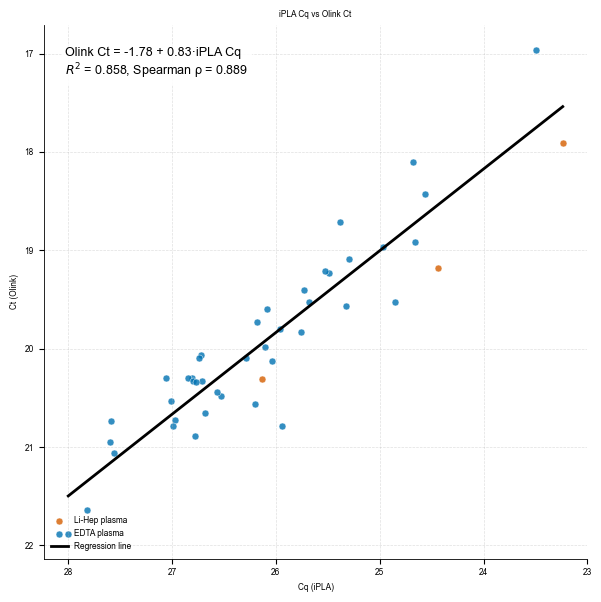

In [11]:
# ── Draft scatter: Olink Ct vs iPLA Cq ───────────────────────────────────────
# Exploratory only. Both axes inverted: high Ct (left/bottom) = low concentration.

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr

df = data.loc[
    data["Ct_global_adjusted"].notna() &
    data["Olink Ct"].notna()
].copy()

x = df["Ct_global_adjusted"]
y = df["Olink Ct"]

X = sm.add_constant(x)
mod = sm.OLS(y, X).fit()
a  = mod.params["const"]
b  = mod.params["Ct_global_adjusted"]
r2 = mod.rsquared
rho, _ = spearmanr(x, y)

x_grid = np.linspace(x.min(), x.max(), 200)
y_fit  = a + b * x_grid

type_colors = {
    "Li-Hep plasma": "#D55E00",
    "EDTA plasma":   "#0072B2",
}

plt.figure(figsize=(6, 6))

if "sample_type" in df.columns:
    for st in df["sample_type"].unique():
        sub = df[df["sample_type"] == st]
        plt.scatter(
            sub["Ct_global_adjusted"], sub["Olink Ct"],
            s=25, alpha=0.8, edgecolor="white", linewidth=0.4,
            label=st, color=type_colors.get(st, "0.5"),
        )
else:
    plt.scatter(x, y, s=25, alpha=0.8, edgecolor="white",
                linewidth=0.4, color="#0072B2", label="Samples")

plt.plot(x_grid, y_fit, color="black", linewidth=2, label="Regression line")

ax = plt.gca()
ax.invert_xaxis()   # high concentration → right
ax.invert_yaxis()   # high concentration → top
ax.set_xlabel("Cq (iPLA)")
ax.set_ylabel("Ct (Olink)")
ax.set_title("iPLA Cq vs Olink Ct")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

txt = (
    f"Olink Ct = {a:.2f} + {b:.2f}·iPLA Cq\n"
    f"$R^2$ = {r2:.3f}, Spearman ρ = {rho:.3f}"
)
ax.text(0.04, 0.96, txt, transform=ax.transAxes,
        ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, linewidth=0))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()


## 12. Final publication plot: iPLA Cq vs Olink Ct

Publication-quality version of the direct Ct comparison. Same house style as cell 9. Both axes inverted so concentration increases toward top-right. Saved as SVG at 300 DPI.

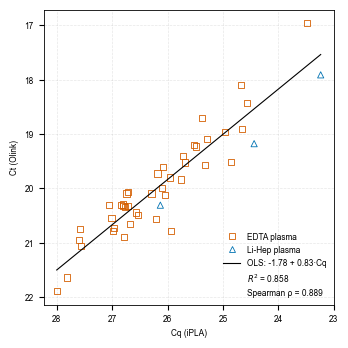

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# ── Global rcParams ───────────────────────────────────────────────────────────
plt.rcParams['font.family']        = 'sans-serif'
plt.rcParams['font.sans-serif']    = ['Helvetica', 'Arial']
plt.rcParams['font.size']          = 6
plt.rcParams['axes.titlesize']     = 6
plt.rcParams['axes.labelsize']     = 6
plt.rcParams['xtick.labelsize']    = 6
plt.rcParams['ytick.labelsize']    = 6
plt.rcParams['legend.fontsize']    = 6
plt.rcParams['axes.linewidth']     = 0.6
plt.rcParams['scatter.edgecolors'] = 'none'

# ── Okabe-Ito palette ─────────────────────────────────────────────────────────
okabe_ito = {
    'orange':         '#E69F00',
    'sky blue':       '#56B4E9',
    'bluish green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermillion':     '#D55E00',
    'reddish purple': '#CC79A7',
    'black':          '#000000',
}
matrix_colours = {
    'EDTA plasma':   okabe_ito['vermillion'],
    'Li-Hep plasma': okabe_ito['blue'],
}
matrix_markers = {
    'EDTA plasma':   's',
    'Li-Hep plasma': '^',
}

# ── Data prep ─────────────────────────────────────────────────────────────────
df = data.loc[
    data["Ct_global_adjusted"].notna() &
    data["Olink Ct"].notna()
].copy()

sample_type_map = {
    'Li Hep Plasma': 'Li-Hep plasma',
    'EDTA Plasma':   'EDTA plasma',
}
df['sample_type'] = df['sample_type'].map(sample_type_map).fillna(df['sample_type'])

x = df["Ct_global_adjusted"]
y = df["Olink Ct"]

# ── OLS regression ────────────────────────────────────────────────────────────
X = sm.add_constant(x)
mod = sm.OLS(y, X).fit()
a   = mod.params["const"]
b   = mod.params["Ct_global_adjusted"]
r2  = mod.rsquared
rho, _ = spearmanr(x, y)

x_grid = np.linspace(x.min(), x.max(), 200)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

if "sample_type" in df.columns:
    for st, sub in df.groupby("sample_type"):
        ax.scatter(
            sub["Ct_global_adjusted"], sub["Olink Ct"],
            s=20, marker=matrix_markers.get(st, 'o'),
            facecolors='none', edgecolors=matrix_colours.get(st, okabe_ito['black']),
            linewidths=0.6, zorder=3
        )
else:
    ax.scatter(
        x, y,
        s=20, marker='o',
        facecolors='none', edgecolors=okabe_ito['blue'],
        linewidths=0.6, zorder=3, label='Samples'
    )

ax.plot(x_grid, a + b * x_grid,
        color=okabe_ito['black'], linewidth=0.8, zorder=4)

ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel('Cq (iPLA)')
ax.set_ylabel('Ct (Olink)')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

# ── Legend ────────────────────────────────────────────────────────────────────
stats_handles = []

if "sample_type" in df.columns:
    for st in matrix_colours:
        if st in df["sample_type"].values:
            stats_handles.append(Line2D(
                [0], [0], marker=matrix_markers.get(st, 'o'), color='none',
                markerfacecolor='none', markeredgecolor=matrix_colours[st],
                markeredgewidth=0.6, markersize=4, label=st
            ))

stats_handles += [
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.8,
           label=f'OLS: {a:.2f} + {b:.2f}·Cq'),
    Line2D([0], [0], color='none', label=f'$R^2$ = {r2:.3f}'),
    Line2D([0], [0], color='none', label=f'Spearman ρ = {rho:.3f}'),
]

ax.legend(handles=stats_handles, frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig('iPLACqvOlinkCt_MiND.svg', dpi=300, bbox_inches='tight')
plt.show()